# **Import Required Libraries**

In [8]:
!pip install imbalanced-learn
!pip install pymongo

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
from pymongo import MongoClient


In [11]:
# Suppress all warnings
import warnings
warnings.filterwarnings('ignore')

# Suppress specific warning categories
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Suppress scikit-learn specific warnings
import sklearn
sklearn.set_config(display='text')  # Reduce output verbosity

# **Load dataset**

In [79]:
df = pd.read_csv("indian_bail_judgments.csv")

print(" DataFrame loaded from CSV")
print(" Shape:", df.shape)
print(df.head())  


 DataFrame loaded from CSV
 Shape: (1200, 25)
   case_id                                         case_title  \
0        1    Jibangshu Paul vs National Investigation Agency   
1        2  State By The Superintendent Of Police vs Mehbo...   
2        3                        Hyderali vs State Of Kerala   
3        4  Rashbehari Karmakar vs Indrajit Mukherjee And ...   
4        5  Smt. Shankri Devi Age 62 Years vs Union Territ...   

                                               court        date  \
0                                 Gauhati High Court  27-07-2011   
1                                  Madras High Court  30-09-1997   
2                                  Kerala High Court  05-08-2008   
3                                Calcutta High Court  12-07-2002   
4  High Court of Jammu & Kashmir and Ladakh at Jammu  12-06-2023   

                                         judge  \
0  Justice I. A. Ansari, Justice A. K. Goswami   
1                       Justice E. Padmanabhan   
2   

In [80]:
import pandas as pd
df = pd.read_csv("indian_bail_judgments.csv")
print(df.columns)


Index(['case_id', 'case_title', 'court', 'date', 'judge', 'ipc_sections',
       'bail_type', 'bail_cancellation_case', 'landmark_case', 'accused_name',
       'accused_gender', 'prior_cases', 'bail_outcome',
       'bail_outcome_label_detailed', 'crime_type', 'facts', 'legal_issues',
       'judgment_reason', 'summary', 'bias_flag', 'parity_argument_used',
       'legal_principles_discussed', 'region', 'source_filename',
       'special_laws'],
      dtype='object')


Store Dataset into MongoDB

In [81]:
# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client['justice_lens']
collection = db['bail_cases']

# Clear existing collection 
collection.delete_many({})

# Insert the dataset
collection.insert_many(df.to_dict(orient="records"))
print(" Local CSV inserted into MongoDB successfully!")


 Local CSV inserted into MongoDB successfully!


In [82]:
# Load all documents from MongoDB
cursor = collection.find()
df = pd.DataFrame(list(cursor))

print("DataFrame shape:", df.shape)
df.head()

DataFrame shape: (1200, 26)


,_id,case_id,case_title,court,date,judge,ipc_sections,bail_type,bail_cancellation_case,landmark_case,...,facts,legal_issues,judgment_reason,summary,bias_flag,parity_argument_used,legal_principles_discussed,region,source_filename,special_laws
0,6908c9f777a5b52d55d5339a,1,Jibangshu Paul vs National Investigation Agency,Gauhati High Court,27-07-2011,"Justice I. A. Ansari, Justice A. K. Goswami","['120B', '121', '121A']",Regular,True,True,...,Jibangshu Paul was apprehended carrying Rs. 32...,"['Whether fresh bail is needed when new, more ...",The court held that newly added serious UA(P) ...,Bail earlier granted to Jibangshu Paul under I...,False,False,['Addition of new penal sections requires fres...,Assam,case0001.PDF,NaN
1,6908c9f777a5b52d55d5339b,2,State By The Superintendent Of Police vs Mehbo...,Madras High Court,30-09-1997,Justice E. Padmanabhan,"['376', '354', '343', '109', '220', '348', '33...",Regular,True,False,...,The case involves custodial rape of a woman by...,['Whether suspension of sentence requires deta...,The court held that due to the grave nature of...,Madras High Court cancelled the bail granted t...,False,False,[],Tamil Nadu,case0002.PDF,NaN
2,6908c9f777a5b52d55d5339c,3,Hyderali vs State Of Kerala,Kerala High Court,05-08-2008,Justice K. Hema,"['465', '468', '471', '474', '420', '511', '34']",Anticipatory,False,True,...,"Hyderali, a government contractor, was accused...",['Whether anticipatory bail can be granted whe...,The court ruled that despite other co-accused ...,Kerala High Court rejected anticipatory bail f...,False,True,['Custodial interrogation is legitimate and ma...,Kerala,case0003.PDF,NaN
3,6908c9f777a5b52d55d5339d,4,Rashbehari Karmakar vs Indrajit Mukherjee And ...,Calcutta High Court,12-07-2002,"Justice P.K. Biswas, Justice S. Barman Roy","['326', '307', '120B', '201']",Regular,True,False,...,"The petitioner, a government employee, alleged...",['Whether bail should be cancelled under Secti...,The court found no cogent or overwhelming reas...,Calcutta High Court refused to cancel bail of ...,False,False,['Difference between grant and cancellation of...,West Bengal,case0004.PDF,NaN
4,6908c9f777a5b52d55d5339e,5,Smt. Shankri Devi Age 62 Years vs Union Territ...,High Court of Jammu & Kashmir and Ladakh at Jammu,12-06-2023,Justice Mohan Lal,"['302', '34']",Regular,False,False,...,Shankri Devi and co-accused were charged with ...,['Whether the court’s earlier bail rejection o...,The court held that its earlier rejection of b...,Jammu & Kashmir High Court rejected the review...,False,False,['Bail once rejected cannot be reviewed except...,Jammu & Kashmir,case0005.PDF,NaN


## **Preprocessing & Feature Engineering**

In [83]:
# Drop rows with missing target
df = df[df['bail_outcome'].notna()]

# Encode label: 1 = Bail Granted, 0 = Denied
df['label'] = df['bail_outcome'].apply(lambda x: 1 if x == 'Granted' else 0)

# Fill missing prior_cases
df['prior_cases'] = df['prior_cases'].fillna(0)

# Gender encoding: Male → 0, Female → 1
df = df[df['accused_gender'].isin(['Male', 'Female'])]  
df['gender_encoded'] = df['accused_gender'].map({'Male': 0, 'Female': 1})

# Encode crime_type as categorical integer
df['crime_type'] = df['crime_type'].fillna('Unknown')
df['crime_type_encoded'] = df['crime_type'].astype('category').cat.codes

# Define features and target
features = ['prior_cases', 'gender_encoded', 'crime_type_encoded']
X = df[features]
y = df['label']

print(" Feature Engineering Completed.")
print(" Features:", features)

 Feature Engineering Completed.
 Features: ['prior_cases', 'gender_encoded', 'crime_type_encoded']


Step 1: Split Data into Train and Test Sets

In [84]:
from sklearn.model_selection import train_test_split

X = df[['prior_cases', 'gender_encoded', 'crime_type_encoded']]
y = df['bail_outcome']  # target column (0 = denied, 1 = granted)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Step 2: Handle Class Imbalance (if needed)

Bail datasets often have more denied than granted cases, so you can use SMOTE or RandomUnderSampler:

In [85]:
# Assuming your original dataframe is df
X = df[['prior_cases', 'gender_encoded', 'crime_type_encoded']]
y = df['bail_outcome']  # your target

Encode prior_cases carefully

In [86]:
# Map 'Yes' → 1, 'No' → 0, 'Unknown' → 0
X['prior_cases'] = X['prior_cases'].map({'Yes': 1, 'No': 0, 'Unknown': 0})

# Ensure no NaN remains
X['prior_cases'].fillna(0, inplace=True)


In [87]:
X = X.astype(float)

In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (955, 3)
X_test shape: (239, 3)


In [89]:
import warnings
warnings.filterwarnings('ignore')

## **Model bulding**

# **Bulidng XGBooost alone**

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Resampled X_train shape:", X_train_res.shape)
print("Resampled y_train shape:", y_train_res.shape)


Resampled X_train shape: (1170, 3)
Resampled y_train shape: (1170,)


In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_res)
y_test_encoded = le.transform(y_test)


In [92]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_res, y_train_encoded)

y_pred = model.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print(classification_report(y_test, y_pred_labels))


Accuracy: 0.602510460251046
              precision    recall  f1-score   support

     Granted       0.74      0.55      0.63       147
    Rejected       0.49      0.68      0.57        92

    accuracy                           0.60       239
   macro avg       0.61      0.62      0.60       239
weighted avg       0.64      0.60      0.61       239



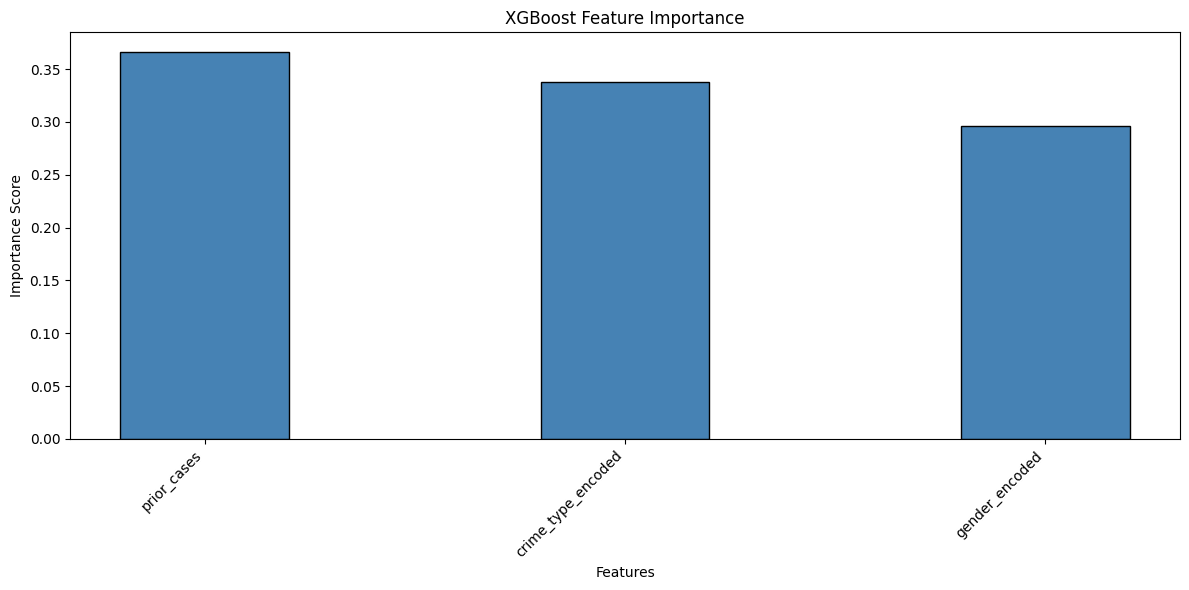


Feature Importance Scores:
              feature  importance
0         prior_cases      0.3664
2  crime_type_encoded      0.3379
1      gender_encoded      0.2957


In [95]:
# ✅ Visualize XGBoost Feature Importance (Reduced Bar Size)
import matplotlib.pyplot as plt

# Get feature importance from XGBoost model
feature_importance_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})
feature_importance_xgb = feature_importance_xgb.sort_values('importance', ascending=False)

# Plot feature importance with reduced bar size
plt.figure(figsize=(12, 6))
plt.bar(
    feature_importance_xgb['feature'],
    feature_importance_xgb['importance'],
    width=0.4,   # 👈 smaller value = thinner bars (try 0.3–0.6 range)
    color='steelblue',
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right')
plt.title('XGBoost Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# Print feature importance scores
print("\nFeature Importance Scores:")
print(feature_importance_xgb.round(4))



## **Random Forest Model Implementation**

In [37]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,  # number of trees
    max_depth=10,      # maximum depth of trees
    random_state=42    # for reproducibility
)

# Fit the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy: 0.6109

Classification Report:
              precision    recall  f1-score   support

     Granted       0.69      0.66      0.68       147
    Rejected       0.49      0.53      0.51        92

    accuracy                           0.61       239
   macro avg       0.59      0.60      0.59       239
weighted avg       0.62      0.61      0.61       239


Confusion Matrix:
[[97 50]
 [43 49]]


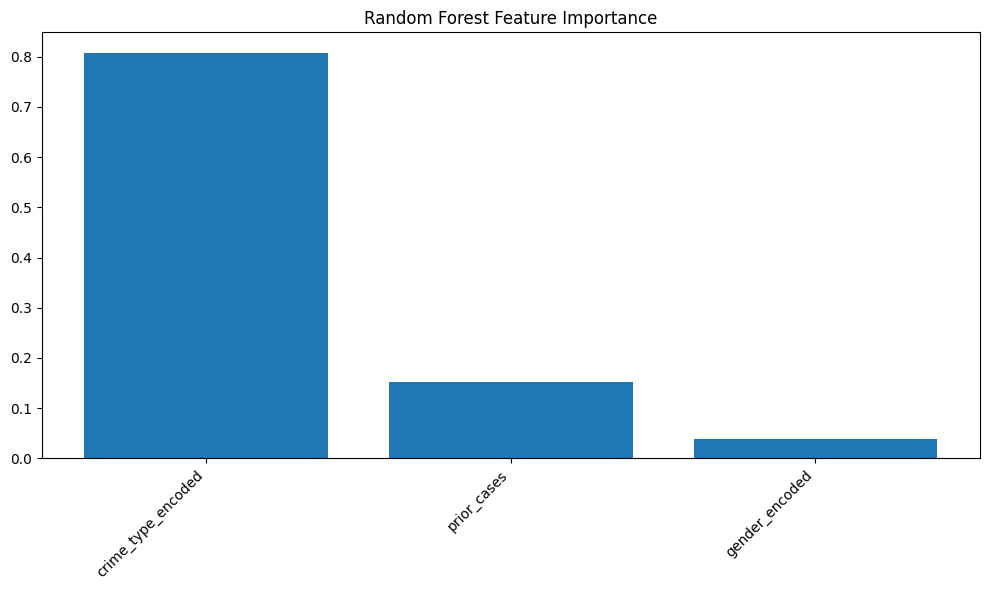


Top 10 Most Important Features:
              feature  importance
2  crime_type_encoded    0.807875
0         prior_cases    0.152575
1      gender_encoded    0.039550


In [38]:
# Visualize feature importance
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# Print top 10 most important features
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

## Logistic Regression Model Implementation

In [39]:
# Import necessary libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Scale the features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,      # increase max iterations for convergence
    random_state=42,    # for reproducibility
    class_weight='balanced'  # handle class imbalance
)

# Fit the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test_scaled)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# Display detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_predictions))

Logistic Regression Accuracy: 0.5858

Classification Report:
              precision    recall  f1-score   support

     Granted       0.68      0.61      0.64       147
    Rejected       0.47      0.55      0.51        92

    accuracy                           0.59       239
   macro avg       0.58      0.58      0.58       239
weighted avg       0.60      0.59      0.59       239


Confusion Matrix:
[[89 58]
 [41 51]]


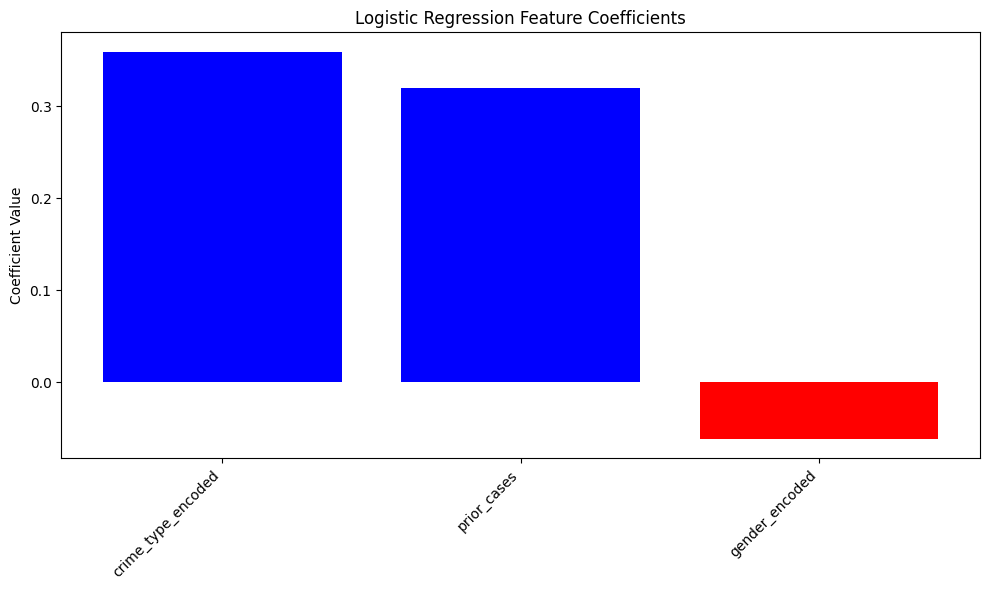


Feature Coefficients (sorted by absolute value):
              feature  coefficient
2  crime_type_encoded       0.3595
0         prior_cases       0.3198
1      gender_encoded      -0.0620


In [40]:
# Analyze feature importance through coefficients
import matplotlib.pyplot as plt

# Get feature coefficients
feature_coef = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
})
feature_coef['abs_coef'] = abs(feature_coef['coefficient'])
feature_coef = feature_coef.sort_values('abs_coef', ascending=False)

# Plot feature coefficients
plt.figure(figsize=(10, 6))
colors = ['blue' if c > 0 else 'red' for c in feature_coef['coefficient']]
plt.bar(feature_coef['feature'], feature_coef['coefficient'], color=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Logistic Regression Feature Coefficients')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()

# Print feature coefficients
print("\nFeature Coefficients (sorted by absolute value):")
print(feature_coef[['feature', 'coefficient']].round(4))

# **To imporve the model**

In [41]:
y = df['label']  # Use numeric labels: 1 = Granted, 0 = Denied

In [42]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5]
}

grid = GridSearchCV(xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                    param_grid=params, cv=3, scoring='f1_weighted', verbose=1)
grid.fit(X_train_res, y_train_encoded)

Fitting 3 folds for each of 972 candidates, totalling 2916 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, gpu_id=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                         

## **Ensemlbe model of XGBClassifier + LogisticRegression + RandomForestClassifier**


In [50]:
import xgboost, sklearn
print("xgboost:", xgboost.__version__)
print("sklearn:", sklearn.__version__)


xgboost: 1.7.6
sklearn: 1.7.0


In [52]:
# ===============================================================
# ✅ Ensemble Model (No Compatibility Issues)
# Using HistGradientBoostingClassifier instead of XGBClassifier
# ===============================================================

from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

# ✅ Define base models
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=6,
    max_iter=300,
    random_state=42
)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

# ✅ Create soft voting ensemble
ensemble = VotingClassifier(
    estimators=[
        ('hgb', hgb_model),
        ('lr', lr_model),
        ('rf', rf_model)
    ],
    voting='soft'
)

# ✅ Train ensemble
ensemble.fit(X_train_res, y_train_encoded)

print("✅ Ensemble VotingClassifier trained successfully using HistGradientBoostingClassifier!")

# ===============================================================
# 🧪 Evaluate Model
# ===============================================================
from sklearn.metrics import accuracy_score, classification_report

y_pred_ensemble = ensemble.predict(X_test)
print("\n Ensemble Model Accuracy:", accuracy_score(y_test_encoded, y_pred_ensemble))
print("\n Classification Report:\n", classification_report(y_test_encoded, y_pred_ensemble))



✅ Ensemble VotingClassifier trained successfully using HistGradientBoostingClassifier!

 Ensemble Model Accuracy: 0.602510460251046

 Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.54      0.62       147
           1       0.49      0.71      0.58        92

    accuracy                           0.60       239
   macro avg       0.62      0.62      0.60       239
weighted avg       0.65      0.60      0.61       239



In [54]:
df = pd.read_csv("indian_bail_judgments.csv")
print(df['bail_outcome'].value_counts(dropna=False))

bail_outcome
Granted     736
Rejected    464
Name: count, dtype: int64


In [55]:
df['bail_outcome'] = df['bail_outcome'].astype(str).str.strip().str.lower()
df['label'] = df['bail_outcome'].apply(lambda x: 1 if x == 'granted' else 0)

In [56]:
print(df.columns.tolist())

['case_id', 'case_title', 'court', 'date', 'judge', 'ipc_sections', 'bail_type', 'bail_cancellation_case', 'landmark_case', 'accused_name', 'accused_gender', 'prior_cases', 'bail_outcome', 'bail_outcome_label_detailed', 'crime_type', 'facts', 'legal_issues', 'judgment_reason', 'summary', 'bias_flag', 'parity_argument_used', 'legal_principles_discussed', 'region', 'source_filename', 'special_laws', 'label']


In [57]:
import numpy as np

# Encode gender
df = df[df['accused_gender'].isin(['Male', 'Female'])]
df['gender_encoded'] = df['accused_gender'].map({'Male': 0, 'Female': 1})

# Encode crime type
df['crime_type'] = df['crime_type'].fillna('Unknown')
df['crime_type_encoded'] = df['crime_type'].astype('category').cat.codes

# Clean prior_cases
df['prior_cases'] = df['prior_cases'].replace({'Yes': 1, 'No': 0, 'Unknown': 0})
df['prior_cases'] = df['prior_cases'].fillna(0).astype(int)

# Create interaction features
df['risk_score'] = df['prior_cases'] * df['gender_encoded']
df['gender_crime_interaction'] = df['gender_encoded'] * df['crime_type_encoded']

# Final feature matrix and target
X = df[['prior_cases', 'gender_encoded', 'crime_type_encoded', 'risk_score', 'gender_crime_interaction']]
y = df['label']

In [58]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X, y, cv=cv, scoring='f1_weighted')

print("Cross-validation F1 scores:", scores)
print("Mean F1 score:", scores.mean())

Cross-validation F1 scores: [0.58131251 0.59704317 0.58983408 0.58119911 0.55969863]
Mean F1 score: 0.5818174980421467


In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# TF-IDF text feature extraction

tfidf = TfidfVectorizer(max_features=500)
text_features = tfidf.fit_transform(df['summary'].fillna("")).toarray()

# Combine structured + text features
structured_features = df[['prior_cases', 'gender_encoded', 'crime_type_encoded', 
                          'risk_score', 'gender_crime_interaction']].values
X_combined = np.hstack([structured_features, text_features])
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)
# Model training and comparison
trained_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Train all models
for name, model in trained_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

# Evaluation function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }

# Compare models
eval_data = []
for name, model in trained_models.items():
    metrics = evaluate_model(model, X_test, y_test)
    eval_data.append([name, metrics["Accuracy"], metrics["Precision"], metrics["Recall"], metrics["F1 Score"]])

# Display comparison
eval_df = pd.DataFrame(eval_data, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
eval_df = eval_df.sort_values("F1 Score", ascending=False)
print("\nModel Performance Comparison:")
print(eval_df)


Training Logistic Regression...
Training Random Forest...
Training XGBoost...

Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.966527   0.986014  0.959184  0.972414
2              XGBoost  0.937238   0.952055  0.945578  0.948805
0  Logistic Regression  0.928870   0.927632  0.959184  0.943144


In [61]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


XGBoost by TD-IDF + GridSearchCV

In [62]:
#TF-IDF on judgment summary
tfidf = TfidfVectorizer(max_features=500)
text_features = tfidf.fit_transform(df['summary'].fillna("")).toarray()

# Combine structured + text features
structured_features = df[['prior_cases', 'gender_encoded', 'crime_type_encoded', 'risk_score', 'gender_crime_interaction']].values
X_combined = np.hstack([structured_features, text_features])
y = df['label']

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)

#Hyperparameter tuning
params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 300],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0, 1],
    'min_child_weight': [1, 3]
}

grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=params,
    cv=3,
    scoring='accuracy',
    verbose=1
)

grid.fit(X_train, y_train)

#Results
print("Best accuracy from GridSearchCV:", grid.best_score_)
print("Best parameters:", grid.best_params_)

Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best accuracy from GridSearchCV: 0.9623035823426195
Best parameters: {'colsample_bytree': 0.7, 'gamma': 1, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.9}


# SHAP

In [63]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    colsample_bytree=0.7,
    gamma=1,
    learning_rate=0.1,
    max_depth=7
    ,
    min_child_weight=1,
    n_estimators=300,
    subsample=0.9
)

final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=1, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

## Explainable AI (XAI) Analysis using SHAP

In [64]:
from xgboost import XGBClassifier
final_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

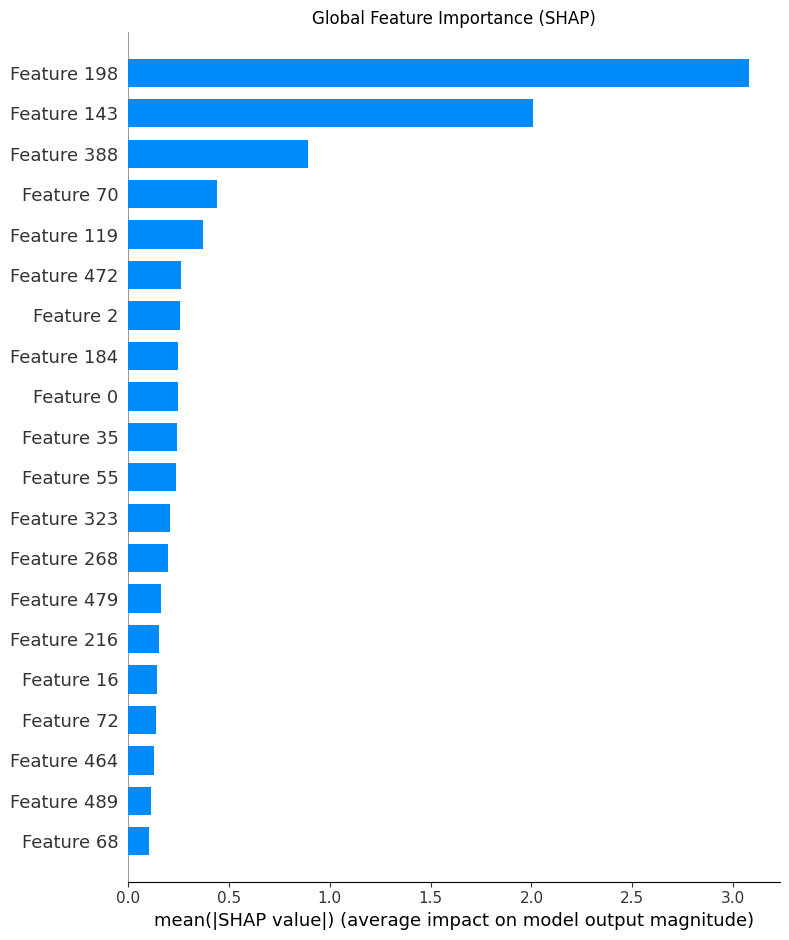

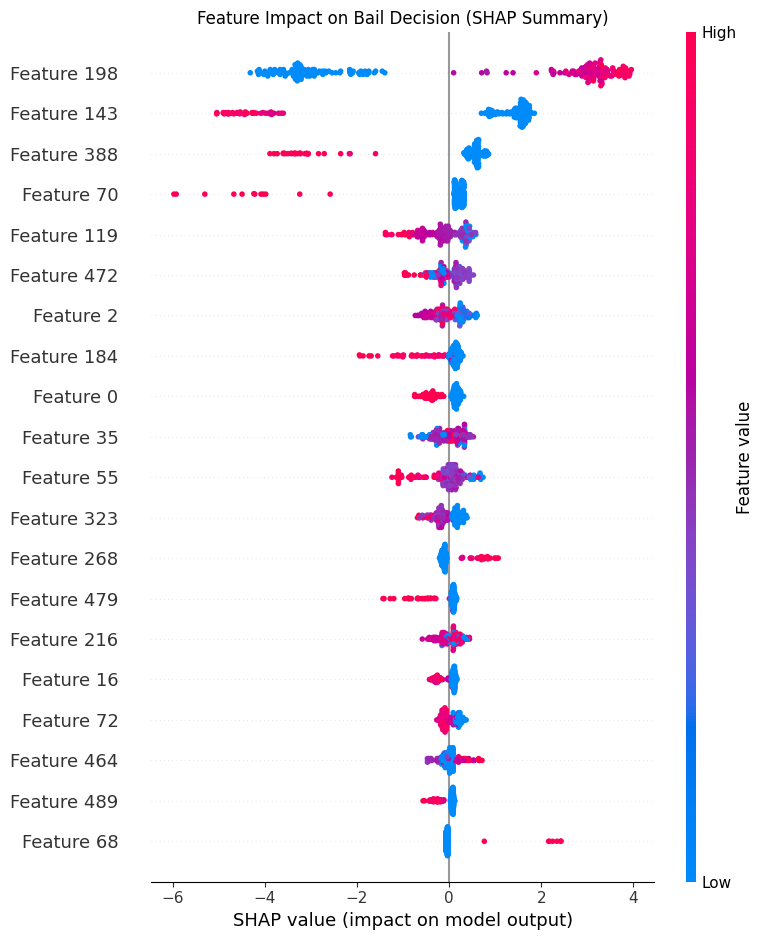

Explaining prediction for test sample index: 144


In [ ]:
#  Explainable AI (XAI) Layer – SHAP for Model Interpretability
import shap
import matplotlib.pyplot as plt
import numpy as np

# Create SHAP Explainer for XGBoost model
explainer = shap.Explainer(final_model, X_train)

# Compute SHAP values for test data
shap_values = explainer(X_test)

# Global Feature Importance (Mean Absolute SHAP Value)

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP)")
plt.tight_layout()
plt.show()

#  Detailed Summary Plot (Feature Impact Distribution)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Impact on Bail Decision (SHAP Summary)")
plt.tight_layout()
plt.show()

#  Individual Prediction Explanation (Local XAI)
# Pick a random sample or index to explain
sample_index = np.random.randint(0, len(X_test))
print(f"Explaining prediction for test sample index: {sample_index}")

In [114]:
# Compute SHAP values
shap_values = explainer(X_test[:100], max_evals=800)


PermutationExplainer explainer: 101it [01:12,  1.38it/s]                         



⏳ Computing SHAP values... (may take a few minutes for large datasets)


  0%|          | 0/50 [00:00<?, ?it/s]

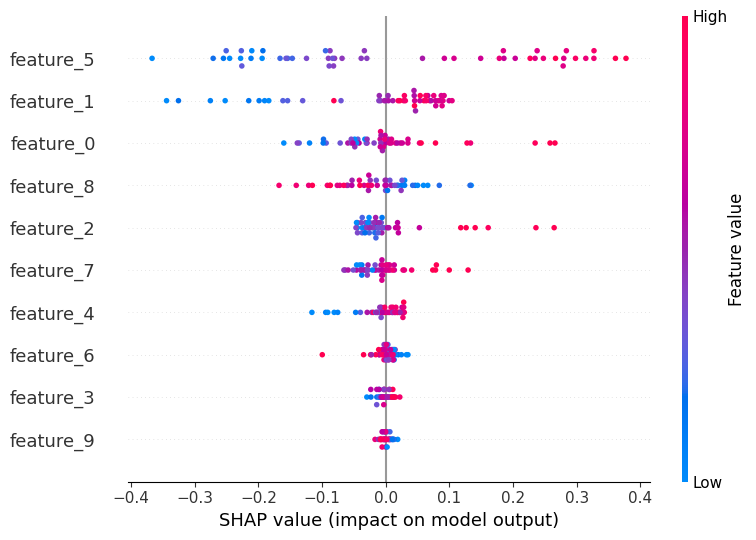

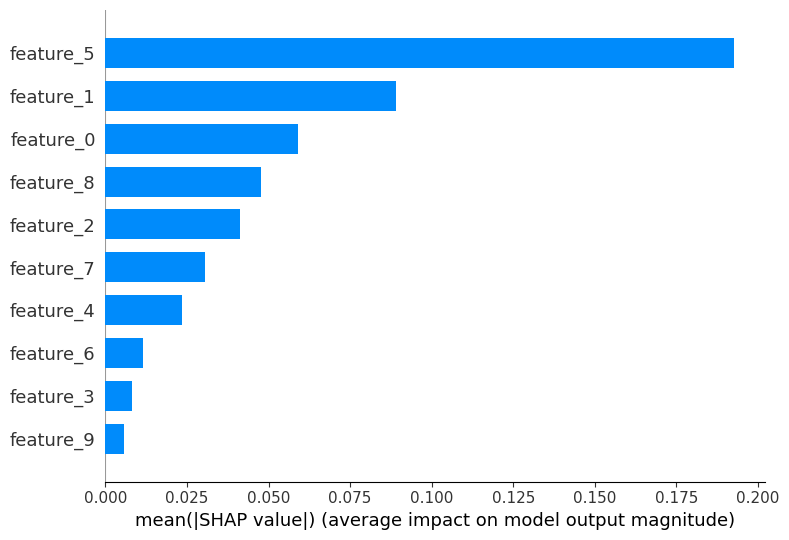

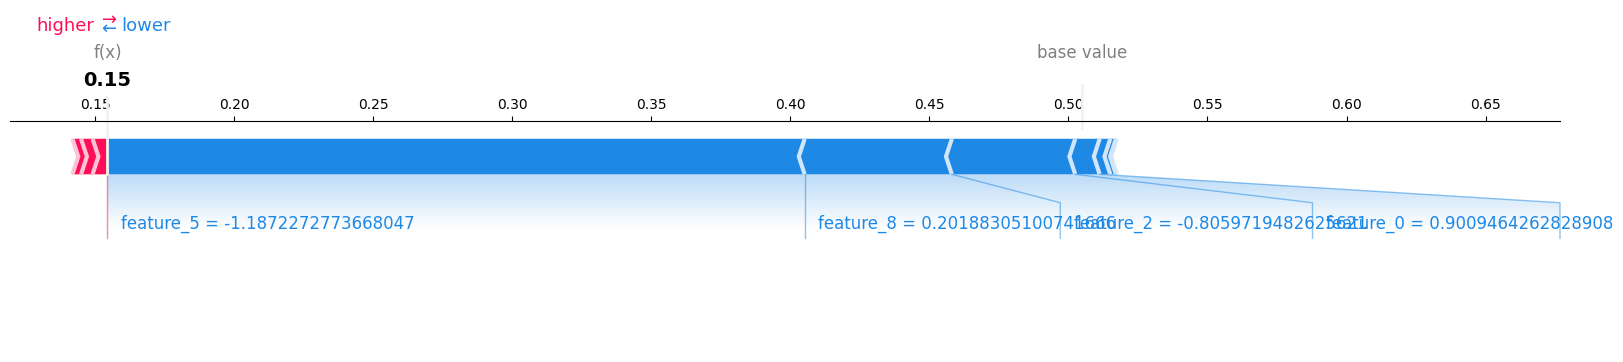

In [ ]:
# Explainable Bail Judgment System — Ensemble + XAI (SHAP)
# Models: HistGradientBoosting + RandomForest + Logistic Regression
import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
# Example Dataset (replace this with your preprocessed bail dataset)
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=800, n_features=10, n_informative=6, 
    n_redundant=2, random_state=42
)
X = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#  Define and Train Base Models
hgb = HistGradientBoostingClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)

for model in [hgb, rf, lr]:
    model.fit(X_train, y_train)
#Create Ensemble Model (Soft Voting)
ensemble = VotingClassifier(
    estimators=[("hgb", hgb), ("rf", rf), ("lr", lr)],
    voting="soft"
)
ensemble.fit(X_train, y_train)
#  SHAP Explainability (Model-Agnostic for all)
# Use KernelExplainer — compatible with any model type
# To make it faster, use a small sample of training data as background
X_background = X_train.sample(100, random_state=42)
X_sample = X_test.sample(50, random_state=42)

# Define unified prediction function
predict_func = lambda data: ensemble.predict_proba(data)[:, 1]

# Initialize KernelExplainer
explainer = shap.KernelExplainer(predict_func, X_background)

# Compute SHAP values
print("⏳ Computing SHAP values... (may take a few minutes for large datasets)")
shap_values = explainer.shap_values(X_sample, nsamples=100)

# Visualizations
shap.summary_plot(shap_values, X_sample, feature_names=X_sample.columns)
shap.summary_plot(shap_values, X_sample, plot_type="bar")

# Single Prediction Explanation
idx = 5
shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    X_sample.iloc[idx, :],
    matplotlib=True
)
